# 🔬 Fingerprint Feature Extraction — Minutiae Detection

This notebook demonstrates Phase 3.1 & 3.2: Detecting Minutiae and Computing Descriptors.

**Steps:** Load preprocessed skeleton -> Crossing Number Detection -> Orientation -> Descriptor -> Template.

In [1]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path(os.path.abspath('')).parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import preprocess
from src.feature_extraction import detect_minutiae, compute_descriptors, visualize_minutiae, create_template

DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'SOCOFing' / 'Real'
print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\Avani\OneDrive\Desktop\fingerprint


## 1. Extract Minutiae from a Real Image

In [2]:
# 1. Run Preprocessing to get the skeleton and mask
sample_path = str(DATA_DIR / '1__M_Left_index_finger.BMP')
pre_result = preprocess(sample_path, return_intermediates=True)

skeleton = pre_result['skeleton']
mask = pre_result['intermediates']['mask']
original = pre_result['intermediates']['original']

# 2. Detect Minutiae (with orientation)
minutiae = detect_minutiae(skeleton, border_margin=15, min_distance=10, mask=mask)

endings = [m for m in minutiae if m[2] == 'ending']
bifurcations = [m for m in minutiae if m[2] == 'bifurcation']

print(f"Total Minutiae Detected: {len(minutiae)}")
print(f"  - Endings: {len(endings)}")
print(f"  - Bifurcations: {len(bifurcations)}")

Total Minutiae Detected: 50
  - Endings: 17
  - Bifurcations: 33


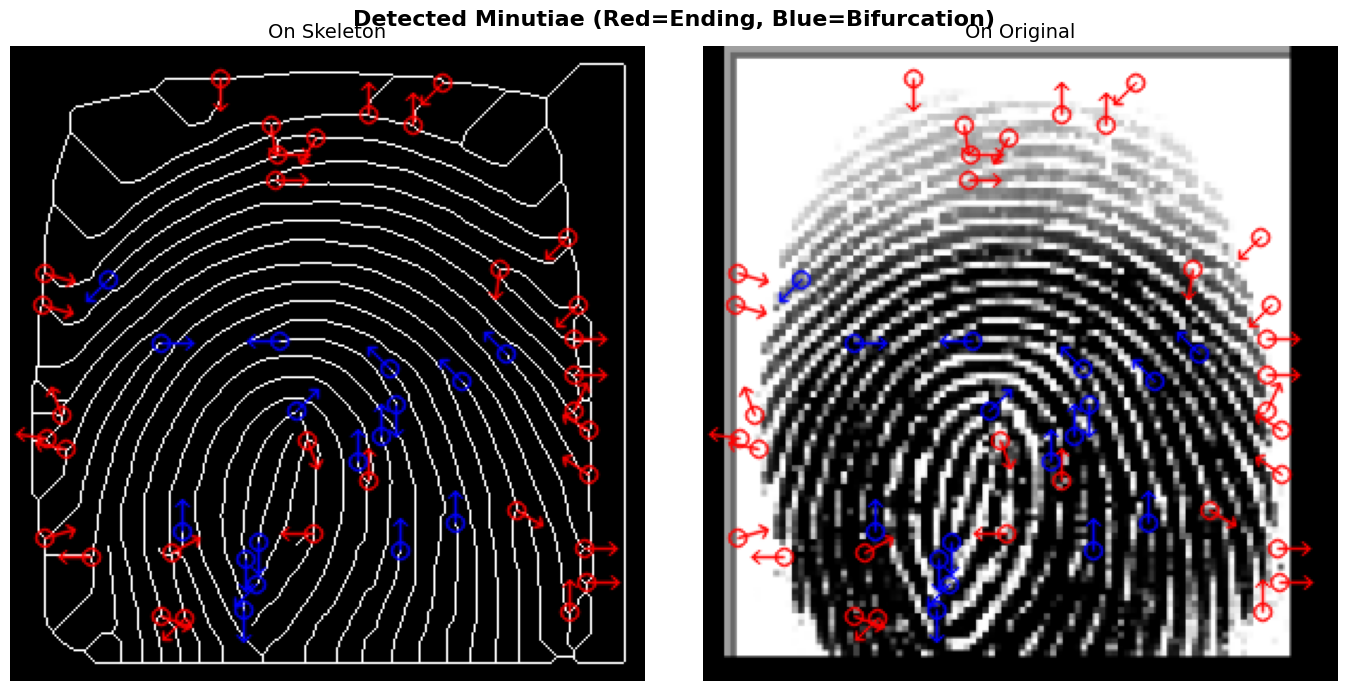

In [3]:
# 3. Visualize Detected Minutiae
# Visualize on skeleton
vis_skel = visualize_minutiae(skeleton, minutiae, show_orientation=True)

# Visualize on original image
vis_orig = visualize_minutiae(original, minutiae, show_orientation=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Detected Minutiae (Red=Ending, Blue=Bifurcation)', fontsize=16, fontweight='bold')

axes[0].imshow(vis_skel)
axes[0].set_title('On Skeleton', fontsize=14)
axes[0].axis('off')

axes[1].imshow(vis_orig)
axes[1].set_title('On Original', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'minutiae_detection_demo.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Minutiae Descriptors and Template Creation

In [4]:
# 4. Compute Descriptors (8 sectors)
descriptors = compute_descriptors(skeleton, minutiae, radius=30, num_sectors=8)
print(f"Computed {len(descriptors)} descriptors, each of size {descriptors[0].shape}.")

# 5. Create Template
template = create_template(minutiae, descriptors, metadata={'subject': 1, 'finger': 'Left Index'})

# Let's look at the first minutia
m1 = template['minutiae'][0]
print("\nSample Minutia:")
print(f"  Location: ({m1['x']}, {m1['y']})")
print(f"  Type: {m1['type']}")
print(f"  Orientation: {m1['orientation']:.2f} rad")
print(f"  Descriptor: {[round(x, 3) for x in m1['descriptor']]}")

Computed 50 descriptors, each of size (8,).

Sample Minutia:
  Location: (15, 122)
  Type: bifurcation
  Orientation: 0.32 rad
  Descriptor: [0.094, 0.111, 0.017, 0.0, 0.0, 0.088, 0.063, 0.031]


## 3. Compare Different Subjects

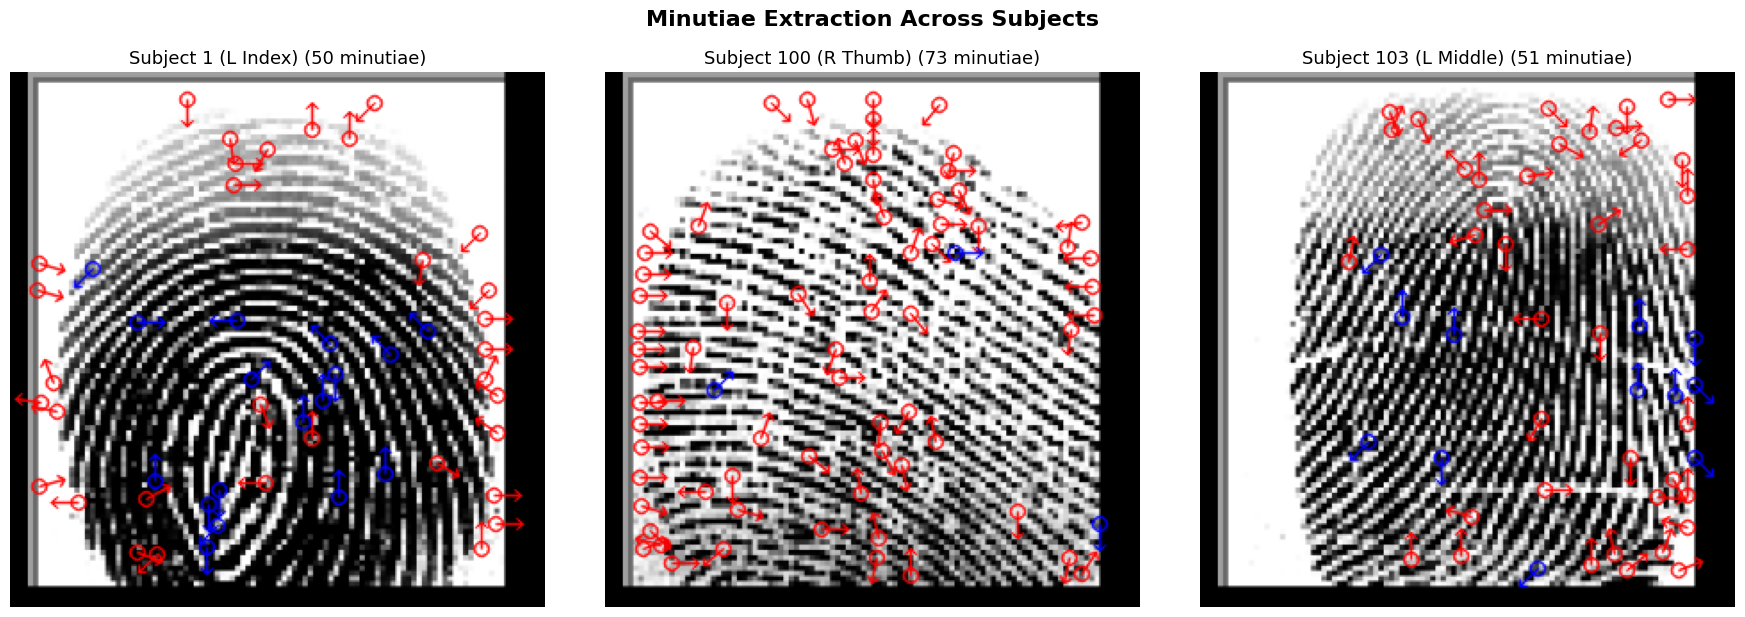

In [5]:
# Run extraction on multiple subjects
subjects = [
    ('Subject 1 (L Index)', '1__M_Left_index_finger.BMP'),
    ('Subject 100 (R Thumb)', '100__M_Right_thumb_finger.BMP'),
    ('Subject 103 (L Middle)', '103__F_Left_middle_finger.BMP'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Minutiae Extraction Across Subjects', fontsize=16, fontweight='bold', y=1.02)

for idx, (label, filename) in enumerate(subjects):
    path = str(DATA_DIR / filename)
    res = preprocess(path, return_intermediates=True)
    skel = res['skeleton']
    mask = res['intermediates']['mask']
    
    mins = detect_minutiae(skel, border_margin=15, min_distance=10, mask=mask)
    
    vis = visualize_minutiae(res['intermediates']['original'], mins, show_orientation=True)
    
    axes[idx].imshow(vis)
    axes[idx].set_title(f"{label} ({len(mins)} minutiae)", fontsize=13)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'minutiae_multi_subjects.png'), dpi=150, bbox_inches='tight')
plt.show()